# ***MODELLING OTHER COMMODITY - NARAPANGAN***

In [ ]:
# Jalankan hanya jika environment belum memiliki dependency modelling.
# !pip install neuralforecast statsforecast prophet scikit-learn lightning -q

## ***IMPORT LIBRARY***

In [1]:
import os
import pickle
import sys
import warnings
import logging
from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score

warnings.filterwarnings("ignore")
logging.getLogger("pytorch_lightning").setLevel(logging.ERROR)
logging.getLogger("cmdstanpy").setLevel(logging.ERROR)

pd.set_option("display.max_columns", 50)

## ***KONFIGURASI KONSTANTA***

In [2]:
HORIZON     = 4
INPUT_SIZE  = 13
N_WINDOWS   = 6
FREQ        = "W-MON"
MAX_STEPS   = 400
RANDOM_SEED = 42

# Ganti ke "cpu" kalau environment tidak punya GPU.
ACCELERATOR = "gpu"
DEVICES     = 1

DATA_DIR = "data"
DATA_START = "2022-01-03"
DATA_END   = "2026-05-01"

MODEL_BASE_DIR = "../backend/narapangan_saved_model"
os.makedirs(MODEL_BASE_DIR, exist_ok=True)

EXOG_COLS = [
    "Garut_T2M_lag8w",
    "Garut_RH2M_lag13w",
    "is_ramadan",
    "is_idul_fitri",
    "is_idul_adha",
]

TELUR_EXOG_COLS = [
    "is_ramadan",
    "is_idul_fitri",
    "is_idul_adha",
]

MODEL_COLS = ["SARIMAX", "Prophet", "LSTM", "NBEATSx", "NHITS"]


## ***FEATURE ENGINEERING TAMBAHAN***

In [3]:
PROJECT_ROOT = Path.cwd().parent
if str(PROJECT_ROOT) not in sys.path:
    sys.path.append(str(PROJECT_ROOT))

from backend.pipeline.nasa_weather import get_nasa_weather_garut
from hijri_converter import Gregorian

weather_cache_path = Path(DATA_DIR) / f"nasa_weather_garut_{DATA_START}_{DATA_END}.csv"

if weather_cache_path.exists():
    garut_weather_daily = pd.read_csv(weather_cache_path)
    garut_weather_daily["Tanggal"] = pd.to_datetime(garut_weather_daily["Tanggal"])
    print(f"Load cache cuaca Garut: {weather_cache_path}")
else:
    garut_weather_daily = get_nasa_weather_garut(DATA_START, DATA_END)
    garut_weather_daily.to_csv(weather_cache_path, index=False)
    print(f"Simpan cache cuaca Garut: {weather_cache_path}")

garut_weather_weekly = (
    garut_weather_daily
    .set_index("Tanggal")
    .resample(FREQ)
    .mean(numeric_only=True)
    .reset_index()
    .rename(columns={"Tanggal": "ds"})
)

garut_weather_weekly["Garut_T2M_lag8w"] = garut_weather_weekly["Garut_T2M"].shift(8)
garut_weather_weekly["Garut_RH2M_lag13w"] = garut_weather_weekly["Garut_RH2M"].shift(13)

daily_dates = pd.date_range(start=DATA_START, end=DATA_END, freq="D")
hijri_daily = pd.DataFrame({"ds": daily_dates})
hijri_daily["is_ramadan"] = 0
hijri_daily["is_idul_fitri"] = 0
hijri_daily["is_idul_adha"] = 0

for idx, row in hijri_daily.iterrows():
    g_date = row["ds"]
    h_date = Gregorian(g_date.year, g_date.month, g_date.day).to_hijri()

    if h_date.month == 9:
        hijri_daily.at[idx, "is_ramadan"] = 1

    if h_date.month == 10 and h_date.day in [1, 2]:
        hijri_daily.at[idx, "is_idul_fitri"] = 1

    if h_date.month == 12 and h_date.day == 10:
        hijri_daily.at[idx, "is_idul_adha"] = 1

hijri_weekly = (
    hijri_daily
    .set_index("ds")
    .resample(FREQ)
    .max()
    .reset_index()
)

exog_weekly = (
    garut_weather_weekly[["ds", "Garut_T2M_lag8w", "Garut_RH2M_lag13w"]]
    .merge(hijri_weekly, on="ds", how="left")
)

print(f"Shape weather harian : {garut_weather_daily.shape}")
print(f"Shape exog mingguan  : {exog_weekly.shape}")
exog_weekly.head(15)

Load cache cuaca Garut: data\nasa_weather_garut_2022-01-03_2026-05-01.csv
Shape weather harian : (1580, 4)
Shape exog mingguan  : (227, 6)


,ds,Garut_T2M_lag8w,Garut_RH2M_lag13w,is_ramadan,is_idul_fitri,is_idul_adha
0,2022-01-03,NaN,NaN,0,0,0
1,2022-01-10,NaN,NaN,0,0,0
2,2022-01-17,NaN,NaN,0,0,0
3,2022-01-24,NaN,NaN,0,0,0
4,2022-01-31,NaN,NaN,0,0,0
5,2022-02-07,NaN,NaN,0,0,0
6,2022-02-14,NaN,NaN,0,0,0
7,2022-02-21,NaN,NaN,0,0,0
8,2022-02-28,22.000000,NaN,0,0,0
9,2022-03-07,23.354286,NaN,0,0,0


## ***BAWANG MERAH - DATA PREPARATION***

In [4]:
BAWANG_MERAH_FILE = f"{DATA_DIR}/pihps_bawang_merah_2022-01-01_2026-05-01.csv"
BAWANG_MERAH_ID   = "bawang_merah_bandung"
BAWANG_MERAH_NAME = "Bawang Merah"

bawang_merah_daily = pd.read_csv(BAWANG_MERAH_FILE)
bawang_merah_daily["tanggal"] = pd.to_datetime(bawang_merah_daily["tanggal"])
bawang_merah_daily = bawang_merah_daily.sort_values("tanggal").reset_index(drop=True)

# Membuat kalender harian kontinu seperti proses cleaning data PIHPS sebelumnya.
full_dates = pd.date_range(
    start=bawang_merah_daily["tanggal"].min(),
    end=bawang_merah_daily["tanggal"].max(),
    freq="D"
)

bawang_merah_daily = (
    bawang_merah_daily
    .set_index("tanggal")
    .reindex(full_dates)
    .ffill()
    .rename_axis("tanggal")
    .reset_index()
)

bawang_merah_daily["komoditas"] = BAWANG_MERAH_NAME
bawang_merah_daily["harga"] = bawang_merah_daily["harga"].astype(float)

print(f"Shape harian : {bawang_merah_daily.shape}")
print(f"Rentang data : {bawang_merah_daily['tanggal'].min().date()} s/d {bawang_merah_daily['tanggal'].max().date()}")
bawang_merah_daily.head()

Shape harian : (1580, 3)
Rentang data : 2022-01-03 s/d 2026-05-01


,tanggal,komoditas,harga
0,2022-01-03,Bawang Merah,28750.0
1,2022-01-04,Bawang Merah,28750.0
2,2022-01-05,Bawang Merah,28750.0
3,2022-01-06,Bawang Merah,28750.0
4,2022-01-07,Bawang Merah,28750.0


In [5]:
bawang_merah_weekly = (
    bawang_merah_daily
    .set_index("tanggal")
    .resample(FREQ)
    .mean(numeric_only=True)
    .reset_index()
    .rename(columns={"tanggal": "ds", "harga": "y"})
)

bawang_merah_weekly = bawang_merah_weekly.merge(exog_weekly, on="ds", how="left")
bawang_merah_weekly["unique_id"] = BAWANG_MERAH_ID
bawang_merah_weekly = bawang_merah_weekly[["unique_id", "ds", "y"] + EXOG_COLS].dropna().reset_index(drop=True)

print(f"Data mingguan : {len(bawang_merah_weekly)} minggu")
print(f"Rentang       : {bawang_merah_weekly['ds'].min().date()} s/d {bawang_merah_weekly['ds'].max().date()}")
print(f"CV windows    : {N_WINDOWS} fold x {HORIZON} minggu")
bawang_merah_weekly.tail()

Data mingguan : 214 minggu
Rentang       : 2022-04-04 s/d 2026-05-04
CV windows    : 6 fold x 4 minggu


,unique_id,ds,y,Garut_T2M_lag8w,Garut_RH2M_lag13w,is_ramadan,is_idul_fitri,is_idul_adha
209,bawang_merah_bandung,2026-04-06,48857.142857,22.827143,89.990000,0,0,0
210,bawang_merah_bandung,2026-04-13,45750.000000,22.932857,89.048571,0,0,0
211,bawang_merah_bandung,2026-04-20,43892.857143,22.578571,87.865714,0,0,0
212,bawang_merah_bandung,2026-04-27,42857.142857,23.028571,90.438571,0,0,0
213,bawang_merah_bandung,2026-05-04,43750.000000,22.595714,90.775714,0,0,0


## ***BAWANG MERAH - VISUALISASI WEEKLY DATA***

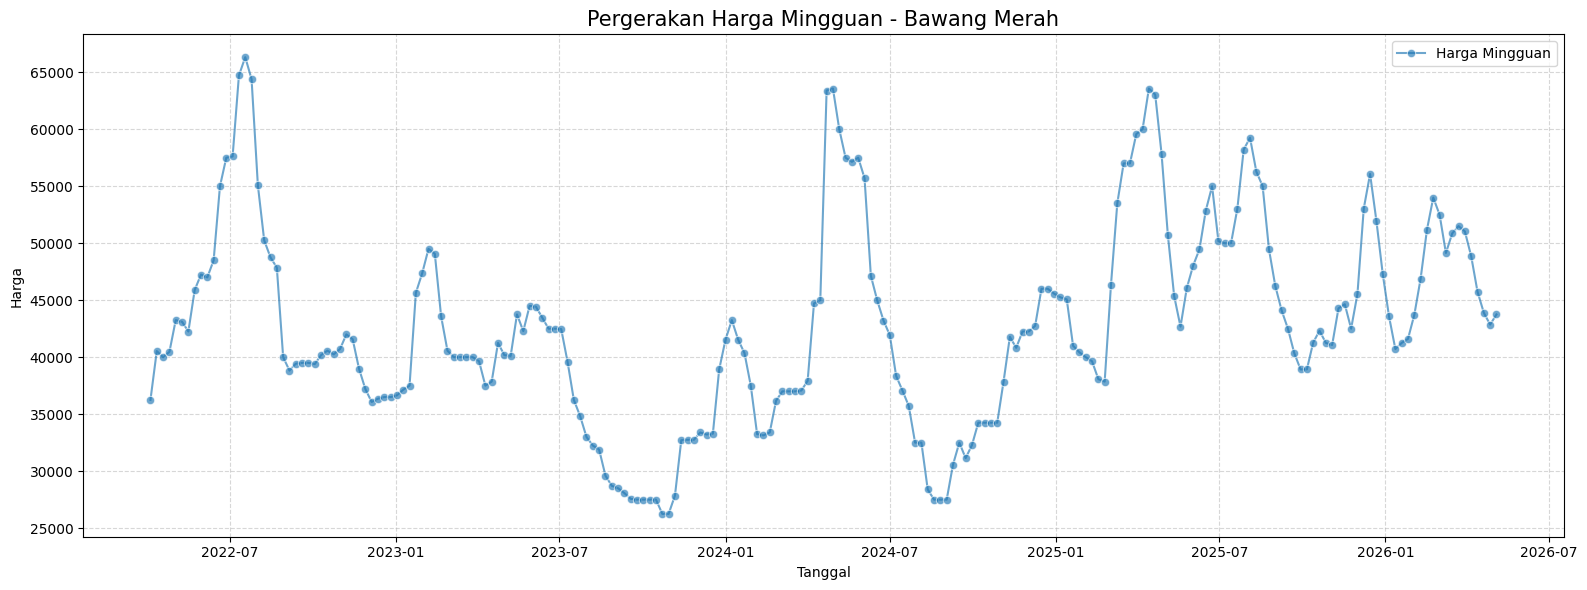

In [6]:
bawang_merah_weekly_plot = bawang_merah_weekly.copy()
bawang_merah_weekly_plot["MA_4"] = bawang_merah_weekly_plot["y"].rolling(window=4, min_periods=1).mean()

plt.figure(figsize=(16, 6))
sns.lineplot(data=bawang_merah_weekly_plot, x="ds", y="y", label="Harga Mingguan", marker="o", alpha=0.65)
# sns.lineplot(data=bawang_merah_weekly_plot, x="ds", y="MA_4", label="Moving Average 4 Minggu", linewidth=2.5)

plt.title("Pergerakan Harga Mingguan - Bawang Merah", fontsize=15)
plt.xlabel("Tanggal")
plt.ylabel("Harga")
plt.grid(True, linestyle="--", alpha=0.5)
plt.legend()
plt.tight_layout()
plt.show()

## ***BAWANG MERAH - MODELLING BASELINE***

### ***SARIMAX / AutoARIMA***

In [7]:
from statsforecast import StatsForecast
from statsforecast.models import AutoARIMA

bawang_merah_sf_df = bawang_merah_weekly[["unique_id", "ds", "y"] + EXOG_COLS].copy()

bawang_merah_sarimax_model = AutoARIMA(
    season_length=52,
    max_p=2,
    max_q=2,
    max_P=1,
    max_Q=1,
    d=1,
    D=1,
    approximation=True,
)

bawang_merah_sf = StatsForecast(
    models=[bawang_merah_sarimax_model],
    freq=FREQ,
    n_jobs=1,
)

bawang_merah_cv_sf = bawang_merah_sf.cross_validation(
    df=bawang_merah_sf_df,
    h=HORIZON,
    n_windows=N_WINDOWS,
    step_size=HORIZON,
    refit=True,
)

bawang_merah_cv_sf = bawang_merah_cv_sf.rename(columns={"AutoARIMA": "SARIMAX"})
bawang_merah_cv_sf = bawang_merah_cv_sf[["unique_id", "ds", "cutoff", "y", "SARIMAX"]]
bawang_merah_cv_sf.head()

,unique_id,ds,cutoff,y,SARIMAX
0,bawang_merah_bandung,2025-11-24,2025-11-17,42500.000000,45329.048301
1,bawang_merah_bandung,2025-12-01,2025-11-17,45535.714286,46055.746997
2,bawang_merah_bandung,2025-12-08,2025-11-17,53035.714286,46201.493961
3,bawang_merah_bandung,2025-12-15,2025-11-17,56071.428571,48138.036879
4,bawang_merah_bandung,2025-12-22,2025-12-15,51964.285714,60972.596436


### ***PROPHET***

In [8]:
from prophet import Prophet

bawang_merah_prophet_preds = []
bawang_merah_total = len(bawang_merah_weekly)
bawang_merah_cutoffs = [
    bawang_merah_total - HORIZON * (N_WINDOWS - i)
    for i in range(N_WINDOWS)
]

for cutoff_idx in bawang_merah_cutoffs:
    train_p = bawang_merah_weekly.iloc[:cutoff_idx][["ds", "y"] + EXOG_COLS].copy()
    test_p = bawang_merah_weekly.iloc[cutoff_idx:cutoff_idx + HORIZON][["ds", "y"] + EXOG_COLS].copy()
    cutoff_date = bawang_merah_weekly["ds"].iloc[cutoff_idx - 1]

    prophet_model = Prophet(
        yearly_seasonality=True,
        weekly_seasonality=False,
        daily_seasonality=False,
        seasonality_mode="additive",
    )

    for exog_col in EXOG_COLS:
        prophet_model.add_regressor(exog_col)

    prophet_model.fit(train_p)

    forecast_p = prophet_model.predict(test_p[["ds"] + EXOG_COLS])
    fold_pred = test_p[["ds", "y"]].copy()
    fold_pred["unique_id"] = BAWANG_MERAH_ID
    fold_pred["cutoff"] = cutoff_date
    fold_pred["Prophet"] = forecast_p["yhat"].values
    bawang_merah_prophet_preds.append(fold_pred[["unique_id", "ds", "cutoff", "y", "Prophet"]])

bawang_merah_cv_prophet = pd.concat(bawang_merah_prophet_preds, ignore_index=True)
bawang_merah_cv_prophet.head()

18:56:01 - cmdstanpy - INFO - Chain [1] start processing
18:56:01 - cmdstanpy - INFO - Chain [1] done processing
18:56:02 - cmdstanpy - INFO - Chain [1] start processing
18:56:02 - cmdstanpy - INFO - Chain [1] done processing
18:56:02 - cmdstanpy - INFO - Chain [1] start processing
18:56:02 - cmdstanpy - INFO - Chain [1] done processing
18:56:02 - cmdstanpy - INFO - Chain [1] start processing
18:56:02 - cmdstanpy - INFO - Chain [1] done processing
18:56:02 - cmdstanpy - INFO - Chain [1] start processing
18:56:02 - cmdstanpy - INFO - Chain [1] done processing
18:56:02 - cmdstanpy - INFO - Chain [1] start processing
18:56:02 - cmdstanpy - INFO - Chain [1] done processing


,unique_id,ds,cutoff,y,Prophet
0,bawang_merah_bandung,2025-11-24,2025-11-17,42500.000000,47784.059509
1,bawang_merah_bandung,2025-12-01,2025-11-17,45535.714286,46197.781221
2,bawang_merah_bandung,2025-12-08,2025-11-17,53035.714286,45552.407278
3,bawang_merah_bandung,2025-12-15,2025-11-17,56071.428571,47638.436256
4,bawang_merah_bandung,2025-12-22,2025-12-15,51964.285714,49820.225326


### ***LSTM, NBEATSx, NHITS***

In [9]:
from neuralforecast import NeuralForecast
from neuralforecast.models import LSTM, NBEATSx, NHITS
from neuralforecast.losses.pytorch import MAE

bawang_merah_nf_df = bawang_merah_weekly[["unique_id", "ds", "y"] + EXOG_COLS].copy()

bawang_merah_nf_models = [
    LSTM(
        h=HORIZON,
        input_size=INPUT_SIZE,
        futr_exog_list=EXOG_COLS,
        max_steps=MAX_STEPS,
        scaler_type="standard",
        loss=MAE(),
        random_seed=RANDOM_SEED,
        accelerator=ACCELERATOR,
        devices=DEVICES,
    ),
    NBEATSx(
        h=HORIZON,
        input_size=INPUT_SIZE,
        futr_exog_list=EXOG_COLS,
        stack_types=["trend", "seasonality"],
        n_blocks=[1, 1],
        mlp_units=2 * [[64, 64]],
        max_steps=MAX_STEPS,
        scaler_type="standard",
        loss=MAE(),
        random_seed=RANDOM_SEED,
        accelerator=ACCELERATOR,
        devices=DEVICES,
    ),
    NHITS(
        h=HORIZON,
        input_size=INPUT_SIZE,
        futr_exog_list=EXOG_COLS,
        n_blocks=[1, 1, 1],
        mlp_units=3 * [[64, 64]],
        max_steps=MAX_STEPS,
        scaler_type="standard",
        loss=MAE(),
        random_seed=RANDOM_SEED,
        accelerator=ACCELERATOR,
        devices=DEVICES,
    ),
]

bawang_merah_nf = NeuralForecast(models=bawang_merah_nf_models, freq=FREQ)

bawang_merah_cv_nf = bawang_merah_nf.cross_validation(
    df=bawang_merah_nf_df,
    n_windows=N_WINDOWS,
    h=HORIZON,
    step_size=HORIZON,
)

bawang_merah_cv_nf.head()

Seed set to 42
Seed set to 42
Seed set to 42
GPU available: True (cuda), used: True
TPU available: False, using: 0 TPU cores
💡 Tip: For seamless cloud logging and experiment tracking, try installing [litlogger](https://pypi.org/project/litlogger/) to enable LitLogger, which logs metrics and artifacts automatically to the Lightning Experiments platform.
You are using a CUDA device ('NVIDIA GeForce RTX 3050 6GB Laptop GPU') that has Tensor Cores. To properly utilize them, you should set `torch.set_float32_matmul_precision('medium' | 'high')` which will trade-off precision for performance. For more details, read https://pytorch.org/docs/stable/generated/torch.set_float32_matmul_precision.html#torch.set_float32_matmul_precision
LOCAL_RANK: 0 - CUDA_VISIBLE_DEVICES: [0]


┏━━━┳━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┳━━━━━━━━┳━━━━━━━┳━━━━━━━┓
┃   ┃ Name         ┃ Type          ┃ Params ┃ Mode  ┃ FLOPs ┃
┡━━━╇━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━╇━━━━━━━━╇━━━━━━━╇━━━━━━━┩
│ 0 │ loss         │ MAE           │      0 │ train │     0 │
│ 1 │ padder_train │ ConstantPad1d │      0 │ train │     0 │
│ 2 │ scaler       │ TemporalNorm  │      0 │ train │     0 │
│ 3 │ hist_encoder │ LSTM          │  201 K │ train │     0 │
│ 4 │ mlp_decoder  │ MLP           │ 17.3 K │ train │     0 │
└───┴──────────────┴───────────────┴────────┴───────┴───────┘

Trainable params: 219 K                                                                                            
Non-trainable params: 0                                                                                            
Total params: 219 K                                                                                                
Total estimated model params size (MB): 0                                                                          
Modules in train mode: 10                                                                                          
Modules in eval mode: 0                                                                                            
Total FLOPs: 0

Output()

`Trainer.fit` stopped: `max_steps=400` reached.


...

Output()

`Trainer.fit` stopped: `max_steps=400` reached.


GPU available: True (cuda), used: True
TPU available: False, using: 0 TPU cores
💡 Tip: For seamless cloud logging and experiment tracking, try installing [litlogger](https://pypi.org/project/litlogger/) to enable LitLogger, which logs metrics and artifacts automatically to the Lightning Experiments platform.
LOCAL_RANK: 0 - CUDA_VISIBLE_DEVICES: [0]


Output()

,unique_id,ds,cutoff,LSTM,NBEATSx,NHITS,y
0,bawang_merah_bandung,2025-11-24,2025-11-17,44476.867188,44856.253906,44238.468750,42500.000000
1,bawang_merah_bandung,2025-12-01,2025-11-17,44063.925781,46817.789062,46489.324219,45535.714286
2,bawang_merah_bandung,2025-12-08,2025-11-17,44208.347656,49139.351562,48384.019531,53035.714286
3,bawang_merah_bandung,2025-12-15,2025-11-17,46185.988281,50698.277344,49594.167969,56071.428571
4,bawang_merah_bandung,2025-12-22,2025-12-15,60315.453125,58562.199219,56644.441406,51964.285714


## ***BAWANG MERAH - LEADERBOARD***

In [12]:
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score

bawang_merah_all_preds = bawang_merah_cv_nf[["unique_id", "ds", "cutoff", "y"]].copy()

bawang_merah_all_preds = bawang_merah_all_preds.merge(
    bawang_merah_cv_sf[["unique_id", "ds", "cutoff", "SARIMAX"]],
    on=["unique_id", "ds", "cutoff"],
    how="left",
)

bawang_merah_all_preds = bawang_merah_all_preds.merge(
    bawang_merah_cv_prophet[["unique_id", "ds", "cutoff", "Prophet"]],
    on=["unique_id", "ds", "cutoff"],
    how="left",
)

for model_col in ["LSTM", "NBEATSx", "NHITS"]:
    if model_col in bawang_merah_cv_nf.columns:
        bawang_merah_all_preds = bawang_merah_all_preds.merge(
            bawang_merah_cv_nf[["unique_id", "ds", "cutoff", model_col]],
            on=["unique_id", "ds", "cutoff"],
            how="left",
        )

bawang_merah_results = []

for model_col in MODEL_COLS:
    subset = bawang_merah_all_preds[["y", model_col]].dropna()
    y_true = subset["y"].values
    y_pred = subset[model_col].values

    mae = mean_absolute_error(y_true, y_pred)
    rmse = np.sqrt(mean_squared_error(y_true, y_pred))
    mape = np.mean(np.abs((y_true - y_pred) / y_true)) * 100
    r2 = r2_score(y_true, y_pred)
    directional_acc = np.mean(np.sign(np.diff(y_true)) == np.sign(np.diff(y_pred))) * 100

    bawang_merah_results.append({
        "Model": model_col,
        "MAE": round(mae, 2),
        "RMSE": round(rmse, 2),
        "MAPE (%)": round(mape, 2),
        "R2": round(r2, 4),
        "Directional Acc (%)": round(directional_acc, 1),
    })

bawang_merah_leaderboard = (
    pd.DataFrame(bawang_merah_results)
    .sort_values("MAE")
    .reset_index(drop=True)
)

bawang_merah_leaderboard.index += 1
bawang_merah_leaderboard.index.name = "Rank"
bawang_merah_leaderboard

,Model,MAE,RMSE,MAPE (%),R2,Directional Acc (%)
Rank,,,,,,
1,NBEATSx,4300.63,6404.05,9.20,-1.0520,56.5
2,NHITS,4589.70,6307.14,9.82,-0.9903,65.2
3,SARIMAX,6959.82,9026.37,15.04,-3.0765,30.4
4,Prophet,7796.15,9353.60,16.88,-3.3774,26.1
5,LSTM,9820.00,12926.93,20.76,-7.3609,52.2


## ***BAWANG MERAH - EVALUATION***

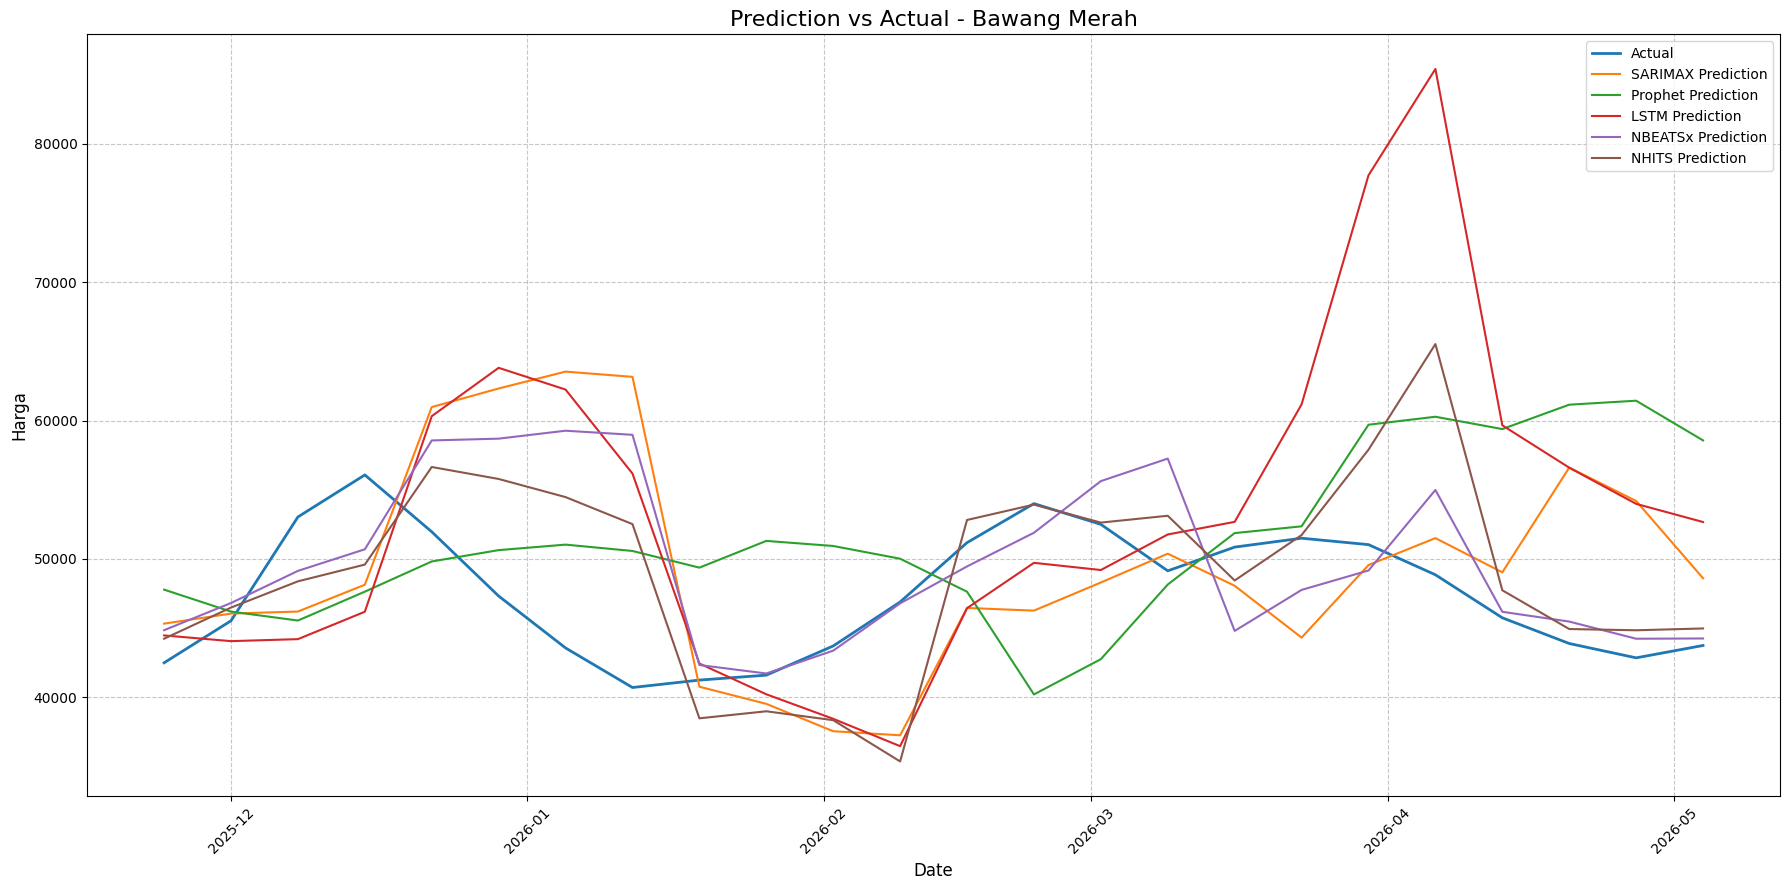

In [13]:
plt.figure(figsize=(18, 9))
sns.lineplot(data=bawang_merah_all_preds, x="ds", y="y", label="Actual", linewidth=2)

for model_col in MODEL_COLS:
    sns.lineplot(data=bawang_merah_all_preds, x="ds", y=model_col, label=f"{model_col} Prediction")

plt.title("Prediction vs Actual - Bawang Merah", fontsize=16)
plt.xlabel("Date", fontsize=12)
plt.ylabel("Harga", fontsize=12)
plt.legend(fontsize=10)
plt.grid(True, linestyle="--", alpha=0.7)
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

In [14]:
bawang_merah_best_model = bawang_merah_leaderboard.iloc[0]["Model"]
print(f"Best model Bawang Merah: {bawang_merah_best_model}")

Best model Bawang Merah: NBEATSx


## ***BAWANG MERAH - SAVE BEST MODEL***

In [15]:
bawang_merah_model_dir = os.path.join(MODEL_BASE_DIR, "bawang_merah_best_model")
os.makedirs(bawang_merah_model_dir, exist_ok=True)

bawang_merah_train_df = bawang_merah_weekly[["unique_id", "ds", "y"] + EXOG_COLS].copy()

if bawang_merah_best_model == "SARIMAX":
    final_model = StatsForecast(
        models=[AutoARIMA(season_length=52, d=1, D=1, approximation=True)],
        freq=FREQ,
        n_jobs=1,
    )
    final_model.fit(df=bawang_merah_train_df)
    model_path = os.path.join(bawang_merah_model_dir, "sarimax.pkl")
    with open(model_path, "wb") as file:
        pickle.dump(final_model, file)

elif bawang_merah_best_model == "Prophet":
    final_model = Prophet(
        yearly_seasonality=True,
        weekly_seasonality=False,
        daily_seasonality=False,
        seasonality_mode="additive",
    )
    for exog_col in EXOG_COLS:
        final_model.add_regressor(exog_col)
    final_model.fit(bawang_merah_train_df[["ds", "y"] + EXOG_COLS])
    model_path = os.path.join(bawang_merah_model_dir, "prophet.pkl")
    with open(model_path, "wb") as file:
        pickle.dump(final_model, file)

else:
    if bawang_merah_best_model == "LSTM":
        final_nf_models = [LSTM(h=HORIZON, input_size=INPUT_SIZE, futr_exog_list=EXOG_COLS, max_steps=MAX_STEPS, scaler_type="standard", loss=MAE(), random_seed=RANDOM_SEED, accelerator=ACCELERATOR, devices=DEVICES)]
    elif bawang_merah_best_model == "NBEATSx":
        final_nf_models = [NBEATSx(h=HORIZON, input_size=INPUT_SIZE, futr_exog_list=EXOG_COLS, stack_types=["trend", "seasonality"], n_blocks=[1, 1], mlp_units=2 * [[64, 64]], max_steps=MAX_STEPS, scaler_type="standard", loss=MAE(), random_seed=RANDOM_SEED, accelerator=ACCELERATOR, devices=DEVICES)]
    else:
        final_nf_models = [NHITS(h=HORIZON, input_size=INPUT_SIZE, futr_exog_list=EXOG_COLS, n_blocks=[1, 1, 1], mlp_units=3 * [[64, 64]], max_steps=MAX_STEPS, scaler_type="standard", loss=MAE(), random_seed=RANDOM_SEED, accelerator=ACCELERATOR, devices=DEVICES)]

    final_model = NeuralForecast(models=final_nf_models, freq=FREQ)
    final_model.fit(df=bawang_merah_train_df)
    final_model.save(path=bawang_merah_model_dir, overwrite=True, save_dataset=False)
    model_path = bawang_merah_model_dir

print(f"Model Bawang Merah tersimpan di: {model_path}")

Seed set to 42
GPU available: True (cuda), used: True
TPU available: False, using: 0 TPU cores
💡 Tip: For seamless cloud logging and experiment tracking, try installing [litlogger](https://pypi.org/project/litlogger/) to enable LitLogger, which logs metrics and artifacts automatically to the Lightning Experiments platform.
LOCAL_RANK: 0 - CUDA_VISIBLE_DEVICES: [0]


┏━━━┳━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┳━━━━━━━━┳━━━━━━━┳━━━━━━━┓
┃   ┃ Name         ┃ Type          ┃ Params ┃ Mode  ┃ FLOPs ┃
┡━━━╇━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━╇━━━━━━━━╇━━━━━━━╇━━━━━━━┩
│ 0 │ loss         │ MAE           │      0 │ train │     0 │
│ 1 │ padder_train │ ConstantPad1d │      0 │ train │     0 │
│ 2 │ scaler       │ TemporalNorm  │      0 │ train │     0 │
│ 3 │ blocks       │ ModuleList    │ 30.6 K │ train │     0 │
└───┴──────────────┴───────────────┴────────┴───────┴───────┘

Trainable params: 30.5 K                                                                                           
Non-trainable params: 153                                                                                          
Total params: 30.6 K                                                                                               
Total estimated model params size (MB): 0                                                                          
Modules in train mode: 20                                                                                          
Modules in eval mode: 0                                                                                            
Total FLOPs: 0

Output()

`Trainer.fit` stopped: `max_steps=400` reached.


Model Bawang Merah tersimpan di: ../backend/narapangan_saved_model\bawang_merah_best_model


## ***BAWANG PUTIH - DATA PREPARATION***

In [17]:
BAWANG_PUTIH_FILE = f"{DATA_DIR}/pihps_bawang_putih_2022-01-01_2026-05-01.csv"
BAWANG_PUTIH_ID   = "bawang_putih_bandung"
BAWANG_PUTIH_NAME = "Bawang Putih"

bawang_putih_daily = pd.read_csv(BAWANG_PUTIH_FILE)
bawang_putih_daily["tanggal"] = pd.to_datetime(bawang_putih_daily["tanggal"])
bawang_putih_daily = bawang_putih_daily.sort_values("tanggal").reset_index(drop=True)

full_dates = pd.date_range(
    start=bawang_putih_daily["tanggal"].min(),
    end=bawang_putih_daily["tanggal"].max(),
    freq="D"
)

bawang_putih_daily = (
    bawang_putih_daily
    .set_index("tanggal")
    .reindex(full_dates)
    .ffill()
    .rename_axis("tanggal")
    .reset_index()
)

bawang_putih_daily["komoditas"] = BAWANG_PUTIH_NAME
bawang_putih_daily["harga"] = bawang_putih_daily["harga"].astype(float)

print(f"Shape harian : {bawang_putih_daily.shape}")
print(f"Rentang data : {bawang_putih_daily['tanggal'].min().date()} s/d {bawang_putih_daily['tanggal'].max().date()}")
bawang_putih_daily.head()

Shape harian : (1580, 3)
Rentang data : 2022-01-03 s/d 2026-05-01


,tanggal,komoditas,harga
0,2022-01-03,Bawang Putih,29250.0
1,2022-01-04,Bawang Putih,29250.0
2,2022-01-05,Bawang Putih,29250.0
3,2022-01-06,Bawang Putih,29250.0
4,2022-01-07,Bawang Putih,29250.0


In [18]:
bawang_putih_weekly = (
    bawang_putih_daily
    .set_index("tanggal")
    .resample(FREQ)
    .mean(numeric_only=True)
    .reset_index()
    .rename(columns={"tanggal": "ds", "harga": "y"})
)

bawang_putih_weekly = bawang_putih_weekly.merge(exog_weekly, on="ds", how="left")
bawang_putih_weekly["unique_id"] = BAWANG_PUTIH_ID
bawang_putih_weekly = bawang_putih_weekly[["unique_id", "ds", "y"] + EXOG_COLS].dropna().reset_index(drop=True)

print(f"Data mingguan : {len(bawang_putih_weekly)} minggu")
print(f"Rentang       : {bawang_putih_weekly['ds'].min().date()} s/d {bawang_putih_weekly['ds'].max().date()}")
print(f"CV windows    : {N_WINDOWS} fold x {HORIZON} minggu")
bawang_putih_weekly.tail()

Data mingguan : 214 minggu
Rentang       : 2022-04-04 s/d 2026-05-04
CV windows    : 6 fold x 4 minggu


,unique_id,ds,y,Garut_T2M_lag8w,Garut_RH2M_lag13w,is_ramadan,is_idul_fitri,is_idul_adha
209,bawang_putih_bandung,2026-04-06,43750.0,22.827143,89.990000,0,0,0
210,bawang_putih_bandung,2026-04-13,43750.0,22.932857,89.048571,0,0,0
211,bawang_putih_bandung,2026-04-20,43750.0,22.578571,87.865714,0,0,0
212,bawang_putih_bandung,2026-04-27,43750.0,23.028571,90.438571,0,0,0
213,bawang_putih_bandung,2026-05-04,43750.0,22.595714,90.775714,0,0,0


## ***BAWANG PUTIH - VISUALISASI WEEKLY DATA***

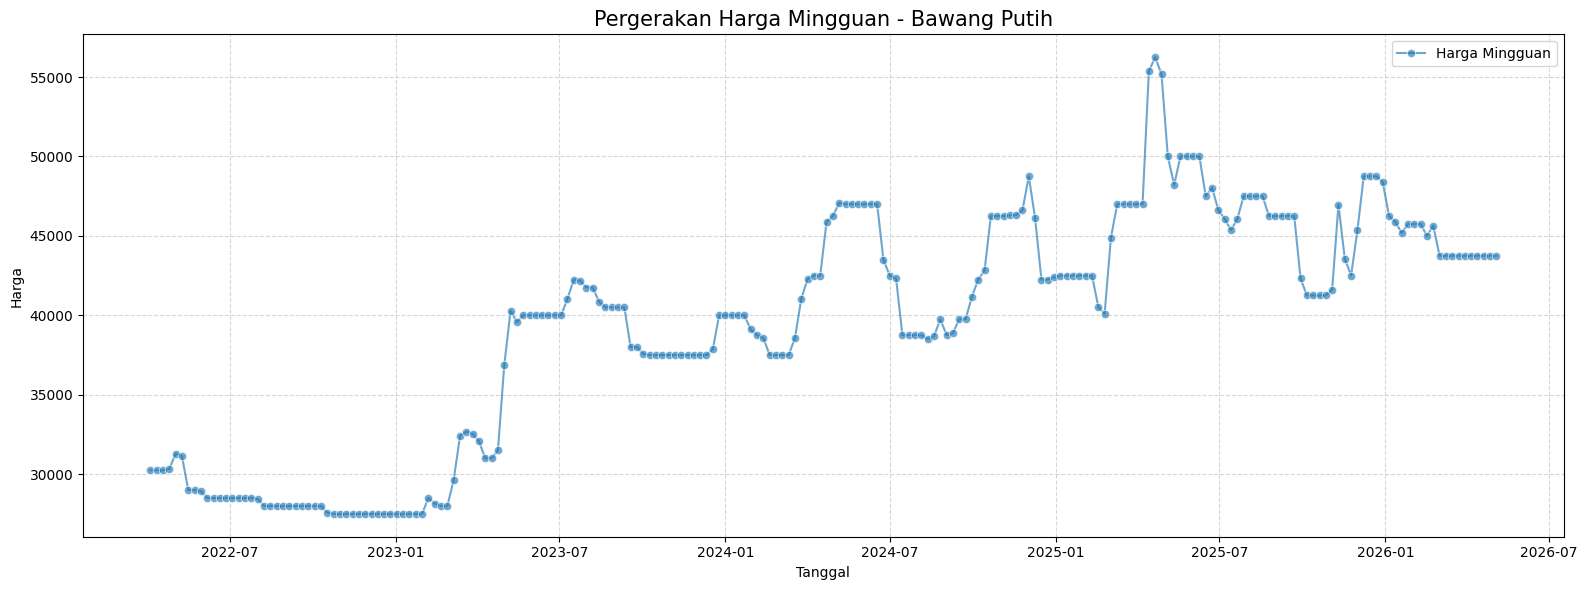

In [19]:
bawang_putih_weekly_plot = bawang_putih_weekly.copy()
bawang_putih_weekly_plot["MA_4"] = bawang_putih_weekly_plot["y"].rolling(window=4, min_periods=1).mean()

plt.figure(figsize=(16, 6))
sns.lineplot(data=bawang_putih_weekly_plot, x="ds", y="y", label="Harga Mingguan", marker="o", alpha=0.65)
# sns.lineplot(data=bawang_putih_weekly_plot, x="ds", y="MA_4", label="Moving Average 4 Minggu", linewidth=2.5)

plt.title("Pergerakan Harga Mingguan - Bawang Putih", fontsize=15)
plt.xlabel("Tanggal")
plt.ylabel("Harga")
plt.grid(True, linestyle="--", alpha=0.5)
plt.legend()
plt.tight_layout()
plt.show()

## ***TELUR AYAM RAS - DATA PREPARATION***


In [20]:
TELUR_FILE = f"{DATA_DIR}/pihps_telur_ayam_ras_2022-01-01_2026-05-01.csv"
TELUR_ID   = "telur_ayam_ras_bandung"
TELUR_NAME = "Telur Ayam Ras"

telur_daily = pd.read_csv(TELUR_FILE)
telur_daily["tanggal"] = pd.to_datetime(telur_daily["tanggal"])
telur_daily = telur_daily.sort_values("tanggal").reset_index(drop=True)

full_dates = pd.date_range(
    start=telur_daily["tanggal"].min(),
    end=telur_daily["tanggal"].max(),
    freq="D"
)

telur_daily = (
    telur_daily
    .set_index("tanggal")
    .reindex(full_dates)
    .ffill()
    .rename_axis("tanggal")
    .reset_index()
)

telur_daily["komoditas"] = TELUR_NAME
telur_daily["harga"] = telur_daily["harga"].astype(float)

print(f"Shape harian : {telur_daily.shape}")
print(f"Rentang data : {telur_daily['tanggal'].min().date()} s/d {telur_daily['tanggal'].max().date()}")
telur_daily.head()


Shape harian : (1580, 3)
Rentang data : 2022-01-03 s/d 2026-05-01


,tanggal,komoditas,harga
0,2022-01-03,Telur Ayam Ras,29000.0
1,2022-01-04,Telur Ayam Ras,29000.0
2,2022-01-05,Telur Ayam Ras,29000.0
3,2022-01-06,Telur Ayam Ras,25000.0
4,2022-01-07,Telur Ayam Ras,25000.0


In [21]:
telur_weekly = (
    telur_daily
    .set_index("tanggal")
    .resample(FREQ)
    .mean(numeric_only=True)
    .reset_index()
    .rename(columns={"tanggal": "ds", "harga": "y"})
)

telur_weekly = telur_weekly.merge(exog_weekly[["ds"] + TELUR_EXOG_COLS], on="ds", how="left")
telur_weekly["unique_id"] = TELUR_ID
telur_weekly = telur_weekly[["unique_id", "ds", "y"] + TELUR_EXOG_COLS].dropna().reset_index(drop=True)

print(f"Data mingguan : {len(telur_weekly)} minggu")
print(f"Rentang       : {telur_weekly['ds'].min().date()} s/d {telur_weekly['ds'].max().date()}")
print(f"CV windows    : {N_WINDOWS} fold x {HORIZON} minggu")
telur_weekly.tail()


Data mingguan : 227 minggu
Rentang       : 2022-01-03 s/d 2026-05-04
CV windows    : 6 fold x 4 minggu


,unique_id,ds,y,is_ramadan,is_idul_fitri,is_idul_adha
222,telur_ayam_ras_bandung,2026-04-06,29821.428571,0,0,0
223,telur_ayam_ras_bandung,2026-04-13,27964.285714,0,0,0
224,telur_ayam_ras_bandung,2026-04-20,27071.428571,0,0,0
225,telur_ayam_ras_bandung,2026-04-27,26642.857143,0,0,0
226,telur_ayam_ras_bandung,2026-05-04,26375.000000,0,0,0


## ***TELUR AYAM RAS - VISUALISASI WEEKLY DATA***


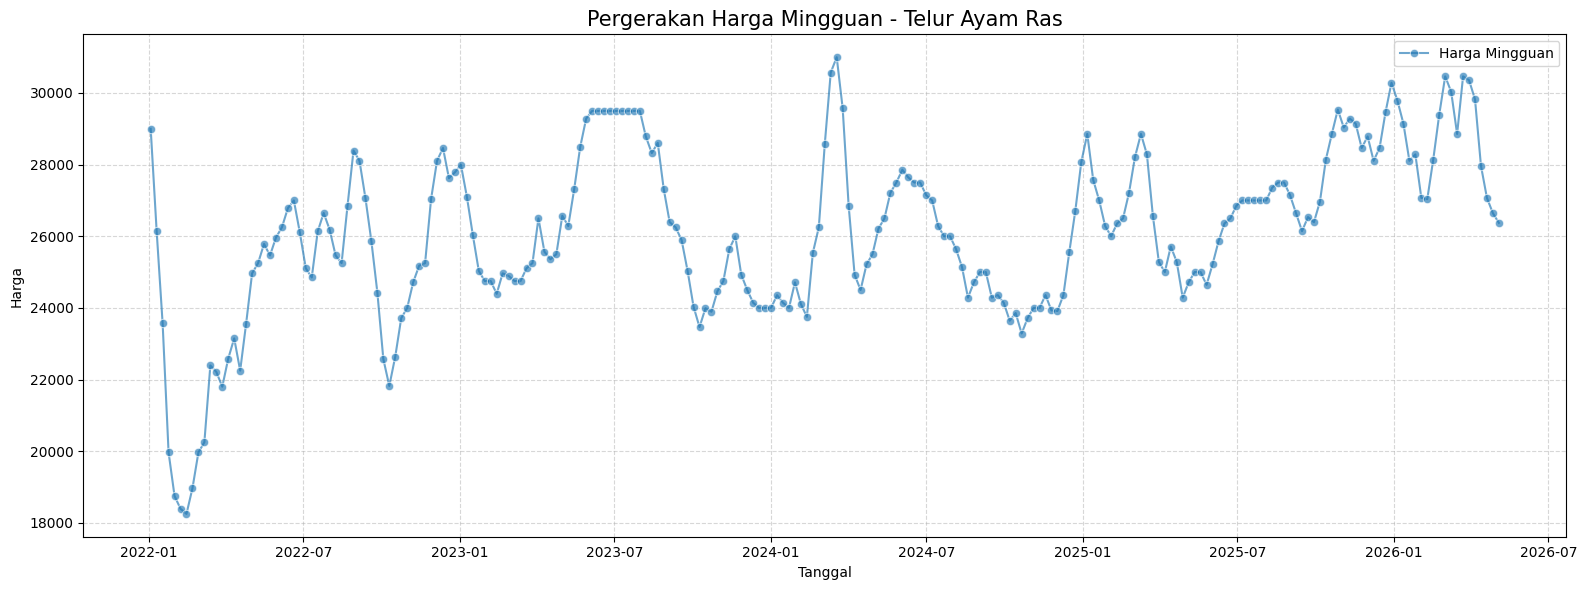

In [22]:
telur_weekly_plot = telur_weekly.copy()
telur_weekly_plot["MA_4"] = telur_weekly_plot["y"].rolling(window=4, min_periods=1).mean()

plt.figure(figsize=(16, 6))
sns.lineplot(data=telur_weekly_plot, x="ds", y="y", label="Harga Mingguan", marker="o", alpha=0.65)
# sns.lineplot(data=telur_weekly_plot, x="ds", y="MA_4", label="Moving Average 4 Minggu", linewidth=2.5)

plt.title("Pergerakan Harga Mingguan - Telur Ayam Ras", fontsize=15)
plt.xlabel("Tanggal")
plt.ylabel("Harga")
plt.grid(True, linestyle="--", alpha=0.5)
plt.legend()
plt.tight_layout()
plt.show()


## ***PERBANDINGAN WEEKLY DATA KOMODITAS***

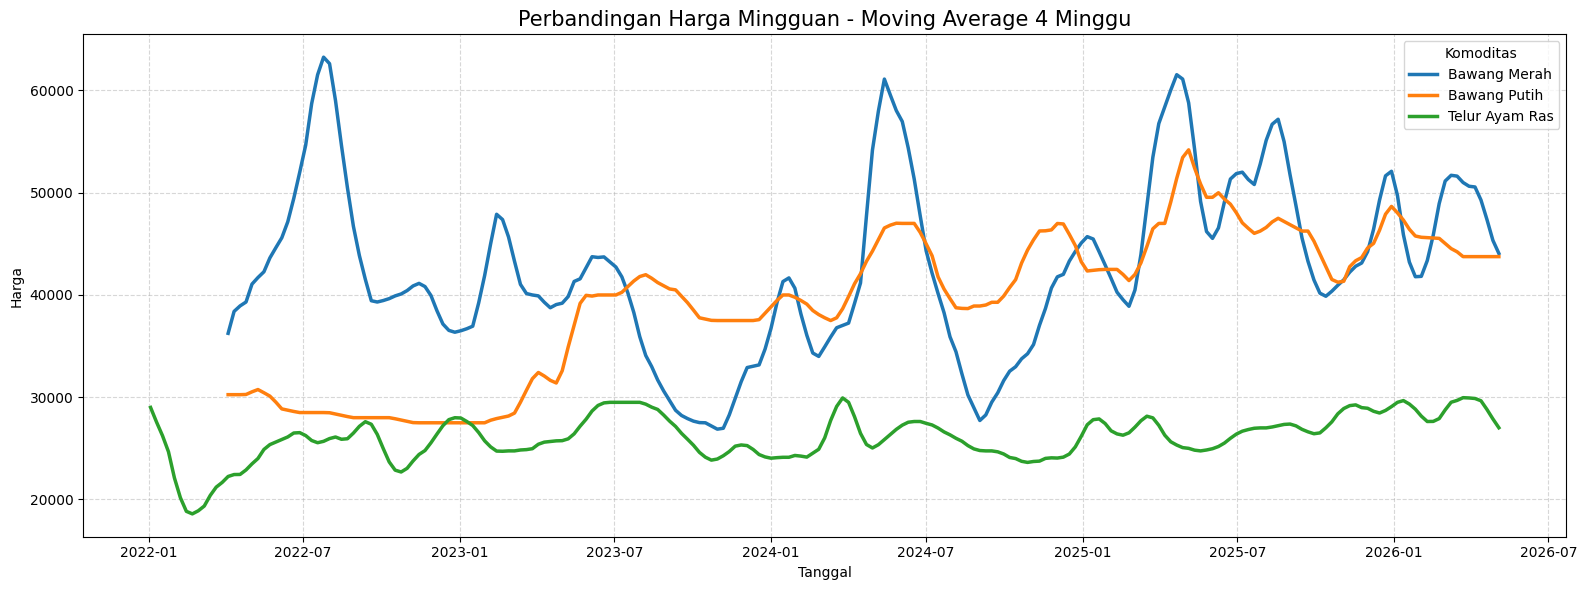

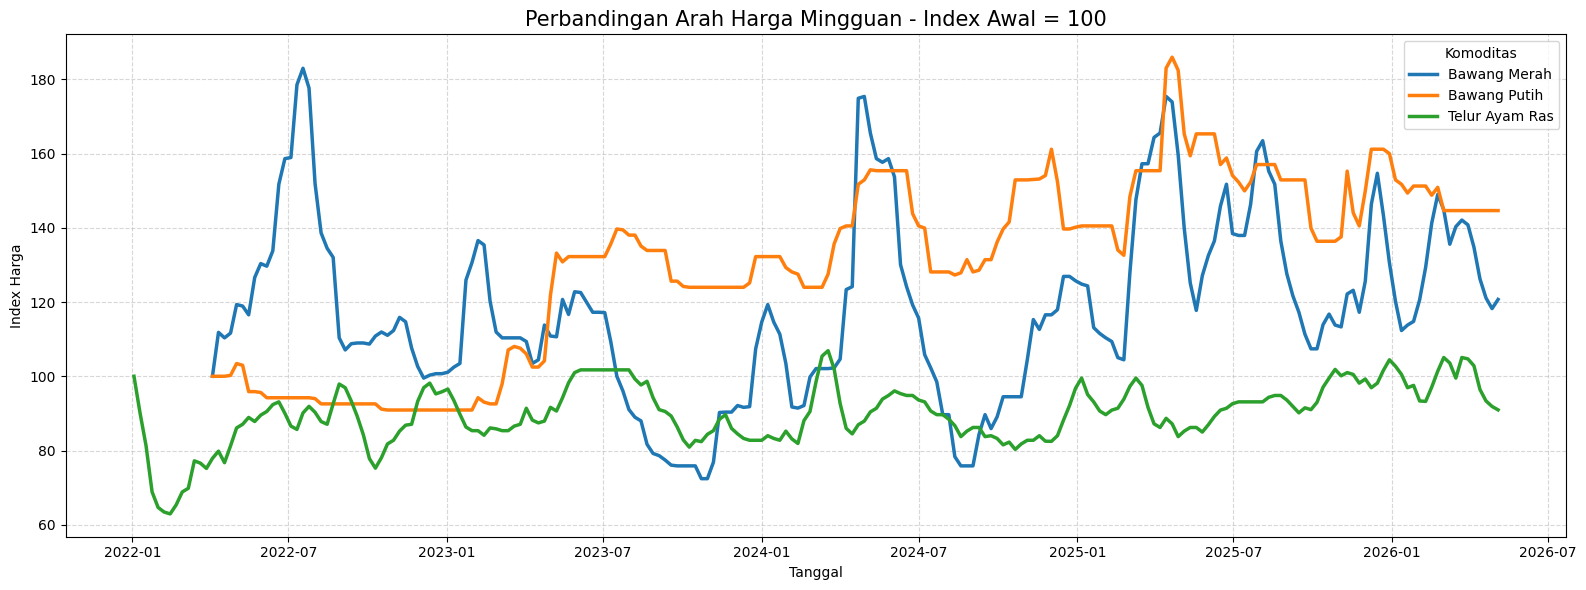

In [23]:
commodity_weekly = pd.concat(
    [
        bawang_merah_weekly.assign(komoditas="Bawang Merah"),
        bawang_putih_weekly.assign(komoditas="Bawang Putih"),
        telur_weekly.assign(komoditas="Telur Ayam Ras"),
    ],
    ignore_index=True,
)

commodity_weekly["MA_4"] = (
    commodity_weekly
    .sort_values(["komoditas", "ds"])
    .groupby("komoditas")["y"]
    .transform(lambda s: s.rolling(window=4, min_periods=1).mean())
)

plt.figure(figsize=(16, 6))
sns.lineplot(data=commodity_weekly, x="ds", y="MA_4", hue="komoditas", linewidth=2.5)

plt.title("Perbandingan Harga Mingguan - Moving Average 4 Minggu", fontsize=15)
plt.xlabel("Tanggal")
plt.ylabel("Harga")
plt.grid(True, linestyle="--", alpha=0.5)
plt.legend(title="Komoditas")
plt.tight_layout()
plt.show()

commodity_weekly_index = commodity_weekly.sort_values(["komoditas", "ds"]).copy()
commodity_weekly_index["harga_index_100"] = (
    commodity_weekly_index
    .groupby("komoditas")["y"]
    .transform(lambda s: s / s.iloc[0] * 100)
)

plt.figure(figsize=(16, 6))
sns.lineplot(data=commodity_weekly_index, x="ds", y="harga_index_100", hue="komoditas", linewidth=2.5)

plt.title("Perbandingan Arah Harga Mingguan - Index Awal = 100", fontsize=15)
plt.xlabel("Tanggal")
plt.ylabel("Index Harga")
plt.grid(True, linestyle="--", alpha=0.5)
plt.legend(title="Komoditas")
plt.tight_layout()


## ***BAWANG PUTIH - MODELLING BASELINE***

### ***SARIMAX / AutoARIMA***

In [24]:
bawang_putih_sf_df = bawang_putih_weekly[["unique_id", "ds", "y"] + EXOG_COLS].copy()

bawang_putih_sarimax_model = AutoARIMA(
    season_length=52,
    max_p=2,
    max_q=2,
    max_P=1,
    max_Q=1,
    d=1,
    D=1,
    approximation=True,
)

bawang_putih_sf = StatsForecast(
    models=[bawang_putih_sarimax_model],
    freq=FREQ,
    n_jobs=1,
)

bawang_putih_cv_sf = bawang_putih_sf.cross_validation(
    df=bawang_putih_sf_df,
    h=HORIZON,
    n_windows=N_WINDOWS,
    step_size=HORIZON,
    refit=True,
)

bawang_putih_cv_sf = bawang_putih_cv_sf.rename(columns={"AutoARIMA": "SARIMAX"})
bawang_putih_cv_sf = bawang_putih_cv_sf[["unique_id", "ds", "cutoff", "y", "SARIMAX"]]
bawang_putih_cv_sf.head()

,unique_id,ds,cutoff,y,SARIMAX
0,bawang_putih_bandung,2025-11-24,2025-11-17,42500.000000,43137.142004
1,bawang_putih_bandung,2025-12-01,2025-11-17,45357.142857,45116.321633
2,bawang_putih_bandung,2025-12-08,2025-11-17,48750.000000,42559.857126
3,bawang_putih_bandung,2025-12-15,2025-11-17,48750.000000,38891.925758
4,bawang_putih_bandung,2025-12-22,2025-12-15,48750.000000,48830.602911


### ***PROPHET***

In [26]:
bawang_putih_prophet_preds = []
bawang_putih_total = len(bawang_putih_weekly)
bawang_putih_cutoffs = [
    bawang_putih_total - HORIZON * (N_WINDOWS - i)
    for i in range(N_WINDOWS)
]

for cutoff_idx in bawang_putih_cutoffs:
    train_p = bawang_putih_weekly.iloc[:cutoff_idx][["ds", "y"] + EXOG_COLS].copy()
    test_p = bawang_putih_weekly.iloc[cutoff_idx:cutoff_idx + HORIZON][["ds", "y"] + EXOG_COLS].copy()
    cutoff_date = bawang_putih_weekly["ds"].iloc[cutoff_idx - 1]

    prophet_model = Prophet(
        yearly_seasonality=True,
        weekly_seasonality=False,
        daily_seasonality=False,
        seasonality_mode="additive",
    )

    for exog_col in EXOG_COLS:
        prophet_model.add_regressor(exog_col)

    prophet_model.fit(train_p)

    forecast_p = prophet_model.predict(test_p[["ds"] + EXOG_COLS])
    fold_pred = test_p[["ds", "y"]].copy()
    fold_pred["unique_id"] = BAWANG_PUTIH_ID
    fold_pred["cutoff"] = cutoff_date
    fold_pred["Prophet"] = forecast_p["yhat"].values
    bawang_putih_prophet_preds.append(fold_pred[["unique_id", "ds", "cutoff", "y", "Prophet"]])

bawang_putih_cv_prophet = pd.concat(bawang_putih_prophet_preds, ignore_index=True)
bawang_putih_cv_prophet.head()

19:28:07 - cmdstanpy - INFO - Chain [1] start processing
19:28:07 - cmdstanpy - INFO - Chain [1] done processing
19:28:07 - cmdstanpy - INFO - Chain [1] start processing
19:28:07 - cmdstanpy - INFO - Chain [1] done processing
19:28:07 - cmdstanpy - INFO - Chain [1] start processing
19:28:07 - cmdstanpy - INFO - Chain [1] done processing
19:28:07 - cmdstanpy - INFO - Chain [1] start processing
19:28:07 - cmdstanpy - INFO - Chain [1] done processing
19:28:07 - cmdstanpy - INFO - Chain [1] start processing
19:28:07 - cmdstanpy - INFO - Chain [1] done processing
19:28:07 - cmdstanpy - INFO - Chain [1] start processing
19:28:07 - cmdstanpy - INFO - Chain [1] done processing


,unique_id,ds,cutoff,y,Prophet
0,bawang_putih_bandung,2025-11-24,2025-11-17,42500.000000,46030.209552
1,bawang_putih_bandung,2025-12-01,2025-11-17,45357.142857,45021.250149
2,bawang_putih_bandung,2025-12-08,2025-11-17,48750.000000,44683.604389
3,bawang_putih_bandung,2025-12-15,2025-11-17,48750.000000,43850.914964
4,bawang_putih_bandung,2025-12-22,2025-12-15,48750.000000,44317.830365


### ***LSTM, NBEATSx, NHITS***

In [27]:
bawang_putih_nf_df = bawang_putih_weekly[["unique_id", "ds", "y"] + EXOG_COLS].copy()

bawang_putih_nf_models = [
    LSTM(
        h=HORIZON,
        input_size=INPUT_SIZE,
        futr_exog_list=EXOG_COLS,
        max_steps=MAX_STEPS,
        scaler_type="standard",
        loss=MAE(),
        random_seed=RANDOM_SEED,
        accelerator=ACCELERATOR,
        devices=DEVICES,
    ),
    NBEATSx(
        h=HORIZON,
        input_size=INPUT_SIZE,
        futr_exog_list=EXOG_COLS,
        stack_types=["trend", "seasonality"],
        n_blocks=[1, 1],
        mlp_units=2 * [[64, 64]],
        max_steps=MAX_STEPS,
        scaler_type="standard",
        loss=MAE(),
        random_seed=RANDOM_SEED,
        accelerator=ACCELERATOR,
        devices=DEVICES,
    ),
    NHITS(
        h=HORIZON,
        input_size=INPUT_SIZE,
        futr_exog_list=EXOG_COLS,
        n_blocks=[1, 1, 1],
        mlp_units=3 * [[64, 64]],
        max_steps=MAX_STEPS,
        scaler_type="standard",
        loss=MAE(),
        random_seed=RANDOM_SEED,
        accelerator=ACCELERATOR,
        devices=DEVICES,
    ),
]

bawang_putih_nf = NeuralForecast(models=bawang_putih_nf_models, freq=FREQ)

bawang_putih_cv_nf = bawang_putih_nf.cross_validation(
    df=bawang_putih_nf_df,
    n_windows=N_WINDOWS,
    h=HORIZON,
    step_size=HORIZON,
)

bawang_putih_cv_nf.head()

Seed set to 42
Seed set to 42
Seed set to 42
GPU available: True (cuda), used: True
TPU available: False, using: 0 TPU cores
💡 Tip: For seamless cloud logging and experiment tracking, try installing [litlogger](https://pypi.org/project/litlogger/) to enable LitLogger, which logs metrics and artifacts automatically to the Lightning Experiments platform.
LOCAL_RANK: 0 - CUDA_VISIBLE_DEVICES: [0]


┏━━━┳━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┳━━━━━━━━┳━━━━━━━┳━━━━━━━┓
┃   ┃ Name         ┃ Type          ┃ Params ┃ Mode  ┃ FLOPs ┃
┡━━━╇━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━╇━━━━━━━━╇━━━━━━━╇━━━━━━━┩
│ 0 │ loss         │ MAE           │      0 │ train │     0 │
│ 1 │ padder_train │ ConstantPad1d │      0 │ train │     0 │
│ 2 │ scaler       │ TemporalNorm  │      0 │ train │     0 │
│ 3 │ hist_encoder │ LSTM          │  201 K │ train │     0 │
│ 4 │ mlp_decoder  │ MLP           │ 17.3 K │ train │     0 │
└───┴──────────────┴───────────────┴────────┴───────┴───────┘

Trainable params: 219 K                                                                                            
Non-trainable params: 0                                                                                            
Total params: 219 K                                                                                                
Total estimated model params size (MB): 0                                                                          
Modules in train mode: 10                                                                                          
Modules in eval mode: 0                                                                                            
Total FLOPs: 0

Output()

`Trainer.fit` stopped: `max_steps=400` reached.


...

Output()

`Trainer.fit` stopped: `max_steps=400` reached.


GPU available: True (cuda), used: True
TPU available: False, using: 0 TPU cores
💡 Tip: For seamless cloud logging and experiment tracking, try installing [litlogger](https://pypi.org/project/litlogger/) to enable LitLogger, which logs metrics and artifacts automatically to the Lightning Experiments platform.
LOCAL_RANK: 0 - CUDA_VISIBLE_DEVICES: [0]


Output()

,unique_id,ds,cutoff,LSTM,NBEATSx,NHITS,y
0,bawang_putih_bandung,2025-11-24,2025-11-17,43188.937500,45201.730469,42021.472656,42500.000000
1,bawang_putih_bandung,2025-12-01,2025-11-17,45488.542969,46239.710938,41127.351562,45357.142857
2,bawang_putih_bandung,2025-12-08,2025-11-17,48899.195312,47322.722656,41589.937500,48750.000000
3,bawang_putih_bandung,2025-12-15,2025-11-17,64981.171875,48684.207031,41594.660156,48750.000000
4,bawang_putih_bandung,2025-12-22,2025-12-15,50164.878906,50926.164062,47859.753906,48750.000000


## ***BAWANG PUTIH - LEADERBOARD***

In [31]:
bawang_putih_all_preds = bawang_putih_cv_nf[["unique_id", "ds", "cutoff", "y"]].copy()

bawang_putih_all_preds = bawang_putih_all_preds.merge(
    bawang_putih_cv_sf[["unique_id", "ds", "cutoff", "SARIMAX"]],
    on=["unique_id", "ds", "cutoff"],
    how="left",
)

bawang_putih_all_preds = bawang_putih_all_preds.merge(
    bawang_putih_cv_prophet[["unique_id", "ds", "cutoff", "Prophet"]],
    on=["unique_id", "ds", "cutoff"],
    how="left",
)

for model_col in ["LSTM", "NBEATSx", "NHITS"]:
    if model_col in bawang_putih_cv_nf.columns:
        bawang_putih_all_preds = bawang_putih_all_preds.merge(
            bawang_putih_cv_nf[["unique_id", "ds", "cutoff", model_col]],
            on=["unique_id", "ds", "cutoff"],
            how="left",
        )

bawang_putih_results = []
for model_col in MODEL_COLS:
    subset = bawang_putih_all_preds[["y", model_col]].dropna()
    y_true = subset["y"].values
    y_pred = subset[model_col].values

    mae = mean_absolute_error(y_true, y_pred)
    rmse = np.sqrt(mean_squared_error(y_true, y_pred))
    mape = np.mean(np.abs((y_true - y_pred) / y_true)) * 100
    r2 = r2_score(y_true, y_pred)
    directional_acc = np.mean(np.sign(np.diff(y_true)) == np.sign(np.diff(y_pred))) * 100

    bawang_putih_results.append({
        "Model": model_col,
        "MAE": round(mae, 2),
        "RMSE": round(rmse, 2),
        "MAPE (%)": round(mape, 2),
        "R2": round(r2, 4),
        "Directional Acc (%)": round(directional_acc, 1),
    })

bawang_putih_leaderboard = (
    pd.DataFrame(bawang_putih_results)
    .sort_values("MAE")
    .reset_index(drop=True)
)

bawang_putih_leaderboard.index += 1
bawang_putih_leaderboard.index.name = "Rank"
bawang_putih_leaderboard

,Model,MAE,RMSE,MAPE (%),R2,Directional Acc (%)
Rank,,,,,,
1,NBEATSx,2844.43,4187.27,6.32,-4.3224,21.7
2,SARIMAX,3141.67,4542.27,6.97,-5.2632,21.7
3,Prophet,3772.25,4624.54,8.41,-5.4921,13.0
4,LSTM,51338.43,117661.59,117.05,-4201.6023,26.1
5,NHITS,86353.65,205518.29,193.64,-12820.8251,30.4


## ***BAWANG PUTIH - EVALUATION***

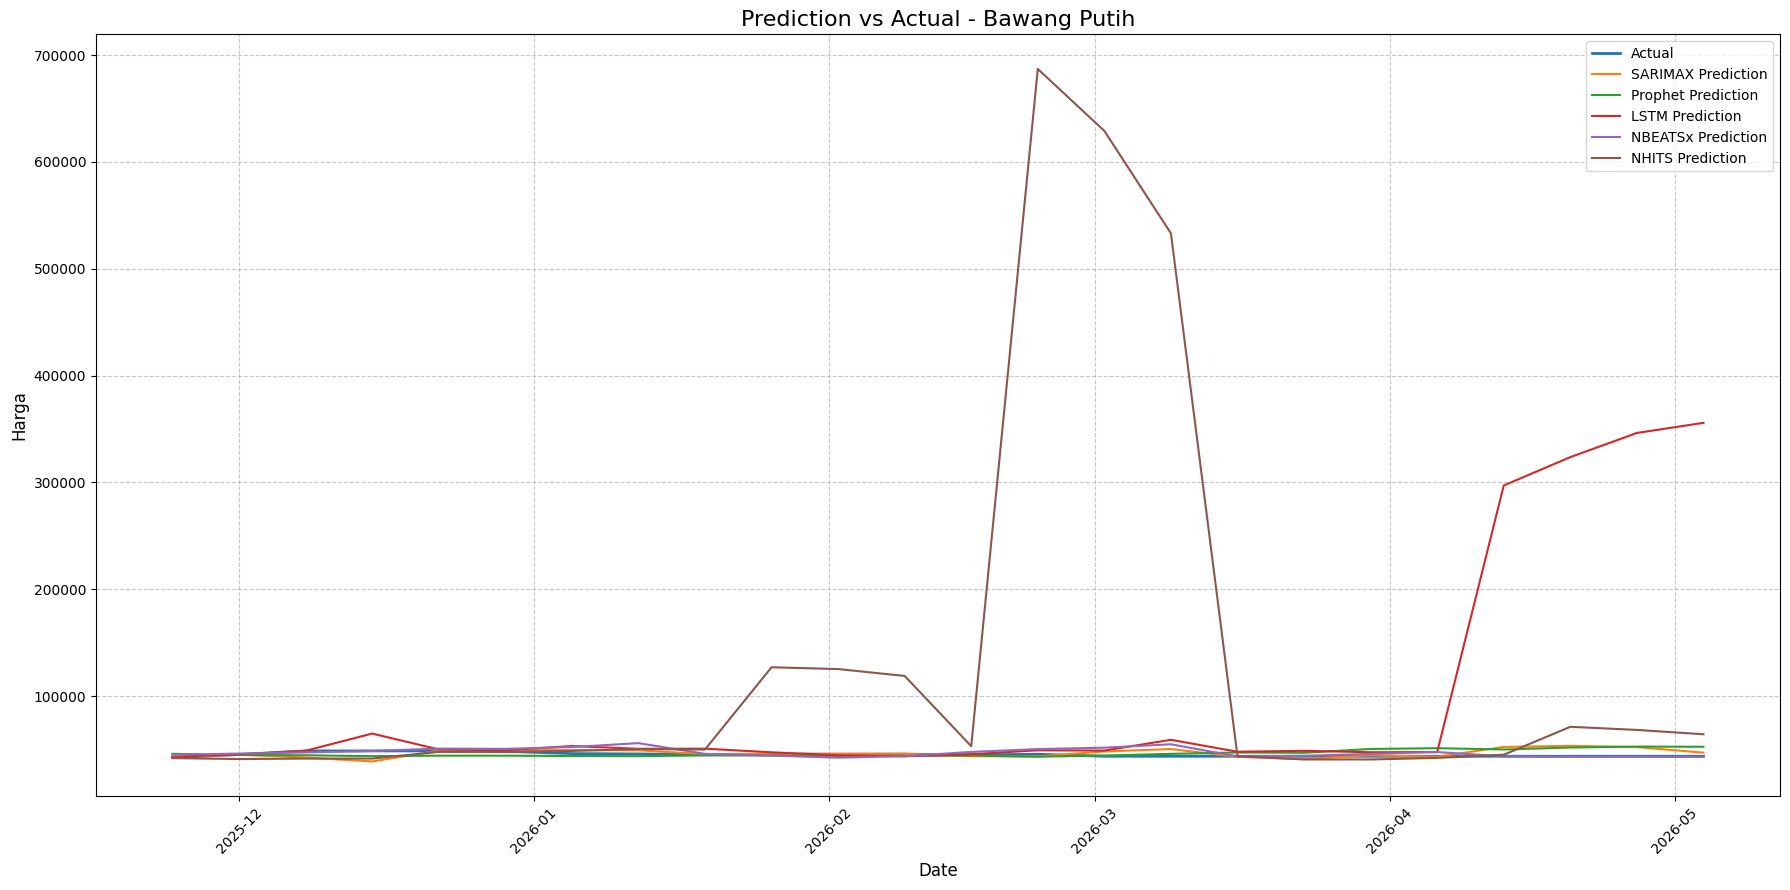

In [32]:
plt.figure(figsize=(18, 9))
sns.lineplot(data=bawang_putih_all_preds, x="ds", y="y", label="Actual", linewidth=2)

for model_col in MODEL_COLS:
    sns.lineplot(data=bawang_putih_all_preds, x="ds", y=model_col, label=f"{model_col} Prediction")

plt.title("Prediction vs Actual - Bawang Putih", fontsize=16)
plt.xlabel("Date", fontsize=12)
plt.ylabel("Harga", fontsize=12)
plt.legend(fontsize=10)
plt.grid(True, linestyle="--", alpha=0.7)
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

In [30]:
bawang_putih_best_model = bawang_putih_leaderboard.iloc[0]["Model"]
print(f"Best model Bawang Putih: {bawang_putih_best_model}")

Best model Bawang Putih: NBEATSx


## ***BAWANG PUTIH - SAVE BEST MODEL***

In [33]:
bawang_putih_model_dir = os.path.join(MODEL_BASE_DIR, "bawang_putih_best_model")
os.makedirs(bawang_putih_model_dir, exist_ok=True)

bawang_putih_train_df = bawang_putih_weekly[["unique_id", "ds", "y"] + EXOG_COLS].copy()

if bawang_putih_best_model == "SARIMAX":
    final_model = StatsForecast(
        models=[AutoARIMA(season_length=52, d=1, D=1, approximation=True)],
        freq=FREQ,
        n_jobs=1,
    )
    final_model.fit(df=bawang_putih_train_df)
    model_path = os.path.join(bawang_putih_model_dir, "sarimax.pkl")
    with open(model_path, "wb") as file:
        pickle.dump(final_model, file)

elif bawang_putih_best_model == "Prophet":
    final_model = Prophet(
        yearly_seasonality=True,
        weekly_seasonality=False,
        daily_seasonality=False,
        seasonality_mode="additive",
    )
    for exog_col in EXOG_COLS:
        final_model.add_regressor(exog_col)
    final_model.fit(bawang_putih_train_df[["ds", "y"] + EXOG_COLS])
    model_path = os.path.join(bawang_putih_model_dir, "prophet.pkl")
    with open(model_path, "wb") as file:
        pickle.dump(final_model, file)

else:
    if bawang_putih_best_model == "LSTM":
        final_nf_models = [LSTM(h=HORIZON, input_size=INPUT_SIZE, futr_exog_list=EXOG_COLS, max_steps=MAX_STEPS, scaler_type="standard", loss=MAE(), random_seed=RANDOM_SEED, accelerator=ACCELERATOR, devices=DEVICES)]
    elif bawang_putih_best_model == "NBEATSx":
        final_nf_models = [NBEATSx(h=HORIZON, input_size=INPUT_SIZE, futr_exog_list=EXOG_COLS, stack_types=["trend", "seasonality"], n_blocks=[1, 1], mlp_units=2 * [[64, 64]], max_steps=MAX_STEPS, scaler_type="standard", loss=MAE(), random_seed=RANDOM_SEED, accelerator=ACCELERATOR, devices=DEVICES)]
    else:
        final_nf_models = [NHITS(h=HORIZON, input_size=INPUT_SIZE, futr_exog_list=EXOG_COLS, n_blocks=[1, 1, 1], mlp_units=3 * [[64, 64]], max_steps=MAX_STEPS, scaler_type="standard", loss=MAE(), random_seed=RANDOM_SEED, accelerator=ACCELERATOR, devices=DEVICES)]

    final_model = NeuralForecast(models=final_nf_models, freq=FREQ)
    final_model.fit(df=bawang_putih_train_df)
    final_model.save(path=bawang_putih_model_dir, overwrite=True, save_dataset=False)
    model_path = bawang_putih_model_dir

print(f"Model Bawang Putih tersimpan di: {model_path}")

Seed set to 42
GPU available: True (cuda), used: True
TPU available: False, using: 0 TPU cores
💡 Tip: For seamless cloud logging and experiment tracking, try installing [litlogger](https://pypi.org/project/litlogger/) to enable LitLogger, which logs metrics and artifacts automatically to the Lightning Experiments platform.
LOCAL_RANK: 0 - CUDA_VISIBLE_DEVICES: [0]


┏━━━┳━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┳━━━━━━━━┳━━━━━━━┳━━━━━━━┓
┃   ┃ Name         ┃ Type          ┃ Params ┃ Mode  ┃ FLOPs ┃
┡━━━╇━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━╇━━━━━━━━╇━━━━━━━╇━━━━━━━┩
│ 0 │ loss         │ MAE           │      0 │ train │     0 │
│ 1 │ padder_train │ ConstantPad1d │      0 │ train │     0 │
│ 2 │ scaler       │ TemporalNorm  │      0 │ train │     0 │
│ 3 │ blocks       │ ModuleList    │ 30.6 K │ train │     0 │
└───┴──────────────┴───────────────┴────────┴───────┴───────┘

Trainable params: 30.5 K                                                                                           
Non-trainable params: 153                                                                                          
Total params: 30.6 K                                                                                               
Total estimated model params size (MB): 0                                                                          
Modules in train mode: 20                                                                                          
Modules in eval mode: 0                                                                                            
Total FLOPs: 0

Output()

`Trainer.fit` stopped: `max_steps=400` reached.


Model Bawang Putih tersimpan di: ../backend/narapangan_saved_model\bawang_putih_best_model


## ***TELUR AYAM RAS - MODELLING BASELINE***


In [34]:
telur_sf_df = telur_weekly[["unique_id", "ds", "y"] + TELUR_EXOG_COLS].copy()

telur_sarimax_model = AutoARIMA(
    season_length=52,
    max_p=2,
    max_q=2,
    max_P=1,
    max_Q=1,
    d=1,
    D=1,
    approximation=True,
)

telur_sf = StatsForecast(
    models=[telur_sarimax_model],
    freq=FREQ,
    n_jobs=1,
)

telur_cv_sf = telur_sf.cross_validation(
    df=telur_sf_df,
    h=HORIZON,
    n_windows=N_WINDOWS,
    step_size=HORIZON,
    refit=True,
)

telur_cv_sf = telur_cv_sf.rename(columns={"AutoARIMA": "SARIMAX"})
telur_cv_sf = telur_cv_sf[["unique_id", "ds", "cutoff", "y", "SARIMAX"]]
telur_cv_sf.head()


,unique_id,ds,cutoff,y,SARIMAX
0,telur_ayam_ras_bandung,2025-11-24,2025-11-17,28464.285714,28422.720838
1,telur_ayam_ras_bandung,2025-12-01,2025-11-17,28785.714286,28419.147545
2,telur_ayam_ras_bandung,2025-12-08,2025-11-17,28107.142857,28567.913275
3,telur_ayam_ras_bandung,2025-12-15,2025-11-17,28464.285714,29011.541336
4,telur_ayam_ras_bandung,2025-12-22,2025-12-15,29464.285714,29375.646856


In [35]:
telur_prophet_preds = []
telur_total = len(telur_weekly)
telur_cutoffs = [
    telur_total - HORIZON * (N_WINDOWS - i)
    for i in range(N_WINDOWS)
]

for cutoff_idx in telur_cutoffs:
    train_p = telur_weekly.iloc[:cutoff_idx][["ds", "y"] + TELUR_EXOG_COLS].copy()
    test_p = telur_weekly.iloc[cutoff_idx:cutoff_idx + HORIZON][["ds", "y"] + TELUR_EXOG_COLS].copy()
    cutoff_date = telur_weekly["ds"].iloc[cutoff_idx - 1]

    prophet_model = Prophet(
        yearly_seasonality=True,
        weekly_seasonality=False,
        daily_seasonality=False,
        seasonality_mode="additive",
    )

    for exog_col in TELUR_EXOG_COLS:
        prophet_model.add_regressor(exog_col)

    prophet_model.fit(train_p)

    forecast_p = prophet_model.predict(test_p[["ds"] + TELUR_EXOG_COLS])
    fold_pred = test_p[["ds", "y"]].copy()
    fold_pred["unique_id"] = TELUR_ID
    fold_pred["cutoff"] = cutoff_date
    fold_pred["Prophet"] = forecast_p["yhat"].values
    telur_prophet_preds.append(fold_pred[["unique_id", "ds", "cutoff", "y", "Prophet"]])

telur_cv_prophet = pd.concat(telur_prophet_preds, ignore_index=True)
telur_cv_prophet.head()


19:30:47 - cmdstanpy - INFO - Chain [1] start processing
19:30:47 - cmdstanpy - INFO - Chain [1] done processing
19:30:47 - cmdstanpy - INFO - Chain [1] start processing
19:30:47 - cmdstanpy - INFO - Chain [1] done processing
19:30:47 - cmdstanpy - INFO - Chain [1] start processing
19:30:47 - cmdstanpy - INFO - Chain [1] done processing
19:30:47 - cmdstanpy - INFO - Chain [1] start processing
19:30:47 - cmdstanpy - INFO - Chain [1] done processing
19:30:47 - cmdstanpy - INFO - Chain [1] start processing
19:30:48 - cmdstanpy - INFO - Chain [1] done processing
19:30:48 - cmdstanpy - INFO - Chain [1] start processing
19:30:48 - cmdstanpy - INFO - Chain [1] done processing


,unique_id,ds,cutoff,y,Prophet
0,telur_ayam_ras_bandung,2025-11-24,2025-11-17,28464.285714,26990.517619
1,telur_ayam_ras_bandung,2025-12-01,2025-11-17,28785.714286,26808.992760
2,telur_ayam_ras_bandung,2025-12-08,2025-11-17,28107.142857,26739.637696
3,telur_ayam_ras_bandung,2025-12-15,2025-11-17,28464.285714,27093.596111
4,telur_ayam_ras_bandung,2025-12-22,2025-12-15,29464.285714,28400.523167


In [36]:
telur_nf_df = telur_weekly[["unique_id", "ds", "y"] + TELUR_EXOG_COLS].copy()

telur_nf_models = [
    LSTM(
        h=HORIZON,
        input_size=INPUT_SIZE,
        futr_exog_list=TELUR_EXOG_COLS,
        max_steps=MAX_STEPS,
        scaler_type="standard",
        loss=MAE(),
        random_seed=RANDOM_SEED,
        accelerator=ACCELERATOR,
        devices=DEVICES,
    ),
    NBEATSx(
        h=HORIZON,
        input_size=INPUT_SIZE,
        futr_exog_list=TELUR_EXOG_COLS,
        stack_types=["trend", "seasonality"],
        n_blocks=[1, 1],
        mlp_units=2 * [[64, 64]],
        max_steps=MAX_STEPS,
        scaler_type="standard",
        loss=MAE(),
        random_seed=RANDOM_SEED,
        accelerator=ACCELERATOR,
        devices=DEVICES,
    ),
    NHITS(
        h=HORIZON,
        input_size=INPUT_SIZE,
        futr_exog_list=TELUR_EXOG_COLS,
        n_blocks=[1, 1, 1],
        mlp_units=3 * [[64, 64]],
        max_steps=MAX_STEPS,
        scaler_type="standard",
        loss=MAE(),
        random_seed=RANDOM_SEED,
        accelerator=ACCELERATOR,
        devices=DEVICES,
    ),
]

telur_nf = NeuralForecast(models=telur_nf_models, freq=FREQ)

telur_cv_nf = telur_nf.cross_validation(
    df=telur_nf_df,
    n_windows=N_WINDOWS,
    h=HORIZON,
    step_size=HORIZON,
)

telur_cv_nf.head()


Seed set to 42
Seed set to 42
Seed set to 42
GPU available: True (cuda), used: True
TPU available: False, using: 0 TPU cores
💡 Tip: For seamless cloud logging and experiment tracking, try installing [litlogger](https://pypi.org/project/litlogger/) to enable LitLogger, which logs metrics and artifacts automatically to the Lightning Experiments platform.
LOCAL_RANK: 0 - CUDA_VISIBLE_DEVICES: [0]


┏━━━┳━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┳━━━━━━━━┳━━━━━━━┳━━━━━━━┓
┃   ┃ Name         ┃ Type          ┃ Params ┃ Mode  ┃ FLOPs ┃
┡━━━╇━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━╇━━━━━━━━╇━━━━━━━╇━━━━━━━┩
│ 0 │ loss         │ MAE           │      0 │ train │     0 │
│ 1 │ padder_train │ ConstantPad1d │      0 │ train │     0 │
│ 2 │ scaler       │ TemporalNorm  │      0 │ train │     0 │
│ 3 │ hist_encoder │ LSTM          │  200 K │ train │     0 │
│ 4 │ mlp_decoder  │ MLP           │ 17.0 K │ train │     0 │
└───┴──────────────┴───────────────┴────────┴───────┴───────┘

Trainable params: 217 K                                                                                            
Non-trainable params: 0                                                                                            
Total params: 217 K                                                                                                
Total estimated model params size (MB): 0                                                                          
Modules in train mode: 10                                                                                          
Modules in eval mode: 0                                                                                            
Total FLOPs: 0

Output()

`Trainer.fit` stopped: `max_steps=400` reached.


...

Output()

`Trainer.fit` stopped: `max_steps=400` reached.


GPU available: True (cuda), used: True
TPU available: False, using: 0 TPU cores
💡 Tip: For seamless cloud logging and experiment tracking, try installing [litlogger](https://pypi.org/project/litlogger/) to enable LitLogger, which logs metrics and artifacts automatically to the Lightning Experiments platform.
LOCAL_RANK: 0 - CUDA_VISIBLE_DEVICES: [0]


Output()

,unique_id,ds,cutoff,LSTM,NBEATSx,NHITS,y
0,telur_ayam_ras_bandung,2025-11-24,2025-11-17,28391.609375,29207.945312,28980.894531,28464.285714
1,telur_ayam_ras_bandung,2025-12-01,2025-11-17,28494.972656,29421.837891,29025.144531,28785.714286
2,telur_ayam_ras_bandung,2025-12-08,2025-11-17,28989.572266,30040.855469,29313.632812,28107.142857
3,telur_ayam_ras_bandung,2025-12-15,2025-11-17,29166.308594,30539.726562,29710.912109,28464.285714
4,telur_ayam_ras_bandung,2025-12-22,2025-12-15,28588.470703,28228.656250,28423.302734,29464.285714


## ***TELUR AYAM RAS - LEADERBOARD***


In [37]:
telur_all_preds = telur_cv_nf[["unique_id", "ds", "cutoff", "y"]].copy()

telur_all_preds = telur_all_preds.merge(
    telur_cv_sf[["unique_id", "ds", "cutoff", "SARIMAX"]],
    on=["unique_id", "ds", "cutoff"],
    how="left",
)

telur_all_preds = telur_all_preds.merge(
    telur_cv_prophet[["unique_id", "ds", "cutoff", "Prophet"]],
    on=["unique_id", "ds", "cutoff"],
    how="left",
)

for model_col in ["LSTM", "NBEATSx", "NHITS"]:
    if model_col in telur_cv_nf.columns:
        telur_all_preds = telur_all_preds.merge(
            telur_cv_nf[["unique_id", "ds", "cutoff", model_col]],
            on=["unique_id", "ds", "cutoff"],
            how="left",
        )

telur_results = []
for model_col in MODEL_COLS:
    subset = telur_all_preds[["y", model_col]].dropna()
    y_true = subset["y"].values
    y_pred = subset[model_col].values

    mae = mean_absolute_error(y_true, y_pred)
    rmse = np.sqrt(mean_squared_error(y_true, y_pred))
    mape = np.mean(np.abs((y_true - y_pred) / y_true)) * 100
    r2 = r2_score(y_true, y_pred)
    directional_acc = np.mean(np.sign(np.diff(y_true)) == np.sign(np.diff(y_pred))) * 100

    telur_results.append({
        "Model": model_col,
        "MAE": round(mae, 2),
        "RMSE": round(rmse, 2),
        "MAPE (%)": round(mape, 2),
        "R2": round(r2, 4),
        "Directional Acc (%)": round(directional_acc, 1),
    })

telur_leaderboard = (
    pd.DataFrame(telur_results)
    .sort_values("MAE")
    .reset_index(drop=True)
)

telur_leaderboard.index += 1
telur_leaderboard.index.name = "Rank"
telur_leaderboard


,Model,MAE,RMSE,MAPE (%),R2,Directional Acc (%)
Rank,,,,,,
1,Prophet,1272.77,1558.38,4.47,-0.5948,52.2
2,SARIMAX,1401.62,1977.89,4.93,-1.5691,56.5
3,NHITS,1971.98,2493.38,6.99,-3.0827,43.5
4,NBEATSx,2605.11,3448.91,9.25,-6.8115,43.5
5,LSTM,3111.44,4634.02,11.19,-13.1021,39.1


## ***TELUR AYAM RAS - EVALUATION***


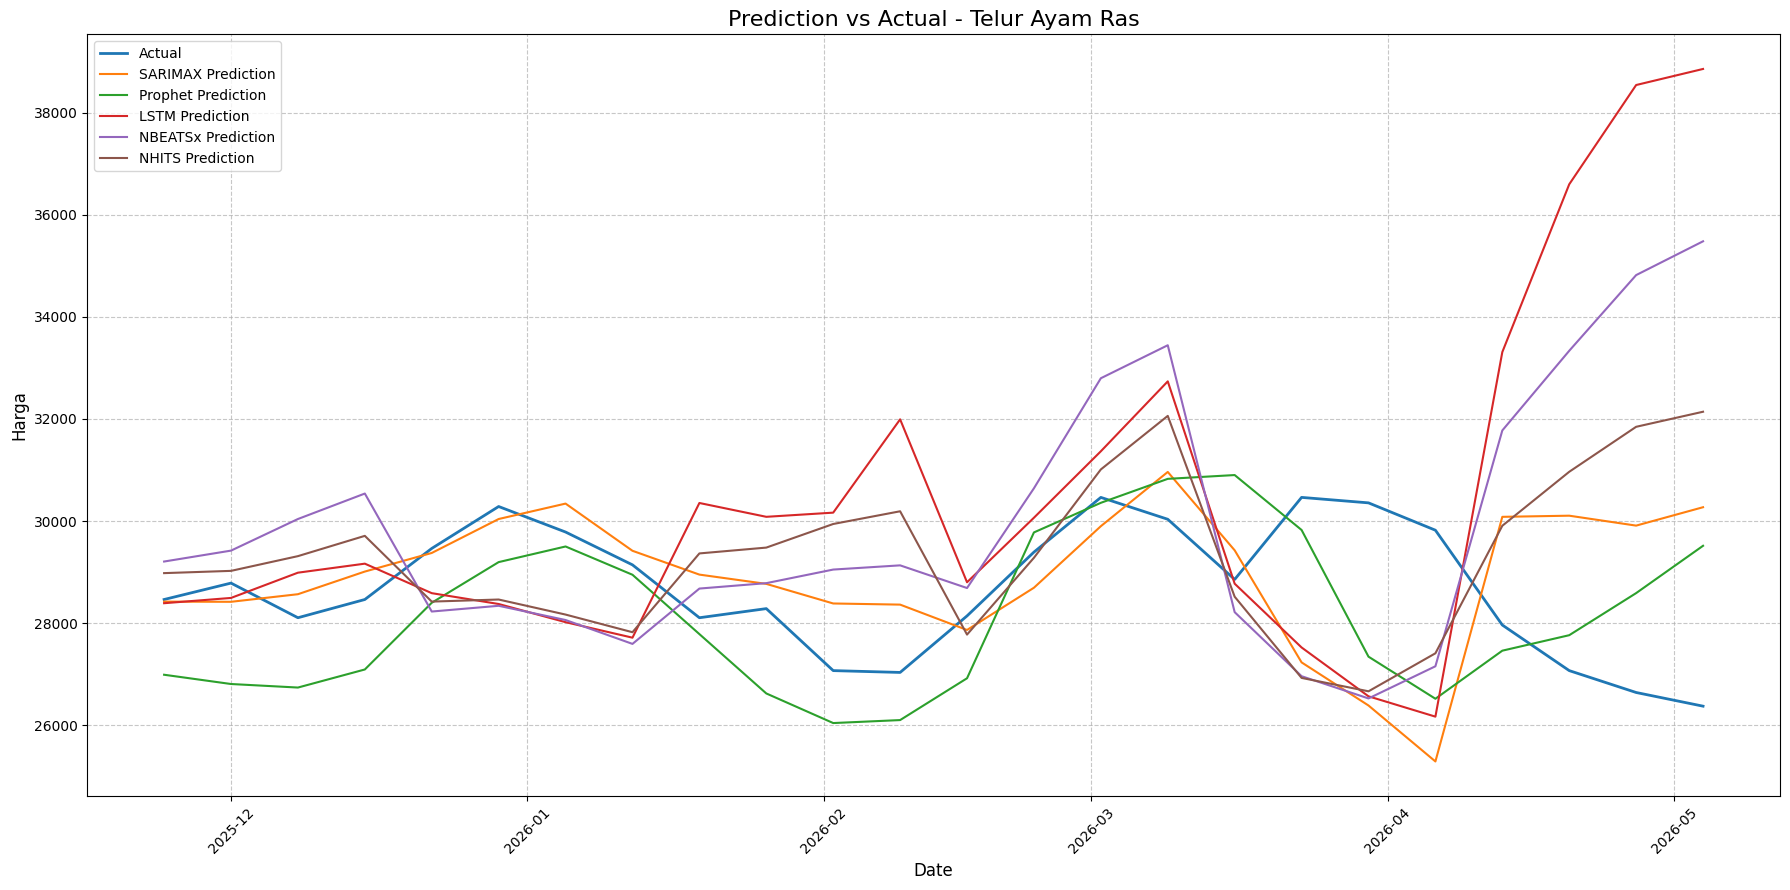

In [38]:
plt.figure(figsize=(18, 9))
sns.lineplot(data=telur_all_preds, x="ds", y="y", label="Actual", linewidth=2)

for model_col in MODEL_COLS:
    sns.lineplot(data=telur_all_preds, x="ds", y=model_col, label=f"{model_col} Prediction")

plt.title("Prediction vs Actual - Telur Ayam Ras", fontsize=16)
plt.xlabel("Date", fontsize=12)
plt.ylabel("Harga", fontsize=12)
plt.legend(fontsize=10)
plt.grid(True, linestyle="--", alpha=0.7)
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()


In [39]:
telur_best_model = telur_leaderboard.iloc[0]["Model"]
print(f"Best model Telur Ayam Ras: {telur_best_model}")


Best model Telur Ayam Ras: Prophet


## ***TELUR AYAM RAS - SAVE BEST MODEL***


In [40]:
telur_model_dir = os.path.join(MODEL_BASE_DIR, "telur_ayam_ras_best_model")
os.makedirs(telur_model_dir, exist_ok=True)

telur_train_df = telur_weekly[["unique_id", "ds", "y"] + TELUR_EXOG_COLS].copy()

if telur_best_model == "SARIMAX":
    final_model = StatsForecast(
        models=[AutoARIMA(season_length=52, d=1, D=1, approximation=True)],
        freq=FREQ,
        n_jobs=1,
    )
    final_model.fit(df=telur_train_df)
    model_path = os.path.join(telur_model_dir, "sarimax.pkl")
    with open(model_path, "wb") as file:
        pickle.dump(final_model, file)

elif telur_best_model == "Prophet":
    final_model = Prophet(
        yearly_seasonality=True,
        weekly_seasonality=False,
        daily_seasonality=False,
        seasonality_mode="additive",
    )
    for exog_col in TELUR_EXOG_COLS:
        final_model.add_regressor(exog_col)
    final_model.fit(telur_train_df[["ds", "y"] + TELUR_EXOG_COLS])
    model_path = os.path.join(telur_model_dir, "prophet.pkl")
    with open(model_path, "wb") as file:
        pickle.dump(final_model, file)

else:
    if telur_best_model == "LSTM":
        final_nf_models = [LSTM(h=HORIZON, input_size=INPUT_SIZE, futr_exog_list=TELUR_EXOG_COLS, max_steps=MAX_STEPS, scaler_type="standard", loss=MAE(), random_seed=RANDOM_SEED, accelerator=ACCELERATOR, devices=DEVICES)]
    elif telur_best_model == "NBEATSx":
        final_nf_models = [NBEATSx(h=HORIZON, input_size=INPUT_SIZE, futr_exog_list=TELUR_EXOG_COLS, stack_types=["trend", "seasonality"], n_blocks=[1, 1], mlp_units=2 * [[64, 64]], max_steps=MAX_STEPS, scaler_type="standard", loss=MAE(), random_seed=RANDOM_SEED, accelerator=ACCELERATOR, devices=DEVICES)]
    else:
        final_nf_models = [NHITS(h=HORIZON, input_size=INPUT_SIZE, futr_exog_list=TELUR_EXOG_COLS, n_blocks=[1, 1, 1], mlp_units=3 * [[64, 64]], max_steps=MAX_STEPS, scaler_type="standard", loss=MAE(), random_seed=RANDOM_SEED, accelerator=ACCELERATOR, devices=DEVICES)]

    final_model = NeuralForecast(models=final_nf_models, freq=FREQ)
    final_model.fit(df=telur_train_df)
    final_model.save(path=telur_model_dir, overwrite=True, save_dataset=False)
    model_path = telur_model_dir

print(f"Model Telur Ayam Ras tersimpan di: {model_path}")


19:32:49 - cmdstanpy - INFO - Chain [1] start processing
19:32:49 - cmdstanpy - INFO - Chain [1] done processing


Model Telur Ayam Ras tersimpan di: ../backend/narapangan_saved_model\telur_ayam_ras_best_model\prophet.pkl


## ***SUMMARY LEADERBOARD***

In [25]:
summary_leaderboard = pd.concat(
    [
        bawang_merah_leaderboard.reset_index().assign(Komoditas="Bawang Merah"),
        bawang_putih_leaderboard.reset_index().assign(Komoditas="Bawang Putih"),
        telur_leaderboard.reset_index().assign(Komoditas="Telur Ayam Ras"),
    ],
    ignore_index=True,
)

summary_leaderboard = summary_leaderboard[
    ["Komoditas", "Rank", "Model", "MAE", "RMSE", "MAPE (%)", "R2", "Directional Acc (%)"]
]


NameError: name 'bawang_merah_leaderboard' is not defined